# Build a `Scene` from other elements

A scene is a composition of three elements:
- A pointsource (`target`)
- A continuum flat background  (`background`)
- A structured background (`host`).

`slicersim.Scene` takes as input these three elements, but they could be left as _None_, resulting to a corresponding null spectrum (np.zeros).

**In that example, we will build a type Ia Supernovae scene that has no host background but zodiacal light**

See examples on how to build a supernovae and a background zodi on dedicated notebooks

***
## A Target : Supernovae

A Supernova need three elements:
- a `model`, i.e. any ojbect that has the `get_flux(phase, lbda)`
- a `position`, (x,y)

For simplicity, model based [sncosmo](https://sncosmo.readthedocs.io/en/stable) have been implemented in `slicersim`.

Let's build from scratch a Supernovae assuming a the "_salt2-extented_" model from [sncosmo](https://sncosmo.readthedocs.io/en/stable) with a _x1=-1_ and _c=0.4_

In [1]:
from slicersim.scene import pointsource

In [2]:
parameters = dict(redshift=0.2, c=0.1, x1=-1) # store true values
model = pointsource.get_saltmodel(**parameters)

In [3]:
position = (-0.4, 2) # position in the slicer

In [4]:
supernovae = pointsource.Supernovae(model=model, position=position, 
                                    meta=parameters)

## A Zodiacal background

In [5]:
from slicersim.scene import background
parameters = {"name": "zodi"}
model_func = background.get_background_model_func("zodi")

In [6]:
bkgd = background.Background(model_func)

## and build the Scene

In [7]:
from slicersim.scene import Scene

In [8]:
sc = Scene(target=supernovae, background=bkgd)

so far the supernovae has no phase set. So let's do that first

In [9]:
sc.update(target__phase=-1) # "__" is parsed as "." as in django

In [10]:
sc.meta

{'target': {'redshift': 0.2,
  'c': 0.1,
  'x1': -1,
  'position': (-0.4, 2),
  'phase': -1},
 'background': {},
 'host': None}

### to get a flux, need a phase and a wavelength

But those could be set as config parameters

In [11]:
import numpy as np
lbda = np.linspace(3_300, 17_000, 500)

In [12]:
lbda, fluxes = sc.get_stacked_spectra(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

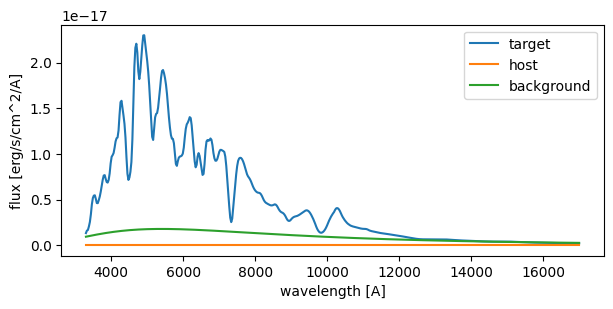

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, fluxes[0], label="target")
ax.plot(lbda, fluxes[1], label="host")
ax.plot(lbda, fluxes[2], label="background")

ax.legend()
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Load Supernovae from a config file

You may want to set the model and position parameters in a config dictionary. 

Just use the `.from_config()` to load a supernovae instance from this configuration

In [14]:
from slicersim import iotools
scene_config = iotools.get_config()["scene"]
scene_config

{'point_source': {'name': 'SN Ia',
  'source': 'salt2-extended',
  'redshift': 1.5,
  'phase': 0,
  'MBmax': -19.3,
  'position': [1, 0.5],
  'c': 0,
  'x1': 0},
 'background': {'name': 'zodi', 'model': 'Aldering01.BB5800', 'scale': 2.0}}

In [17]:
scene = Scene.from_config(scene_config)

In [18]:
lbda, fluxes = scene.get_stacked_spectra(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

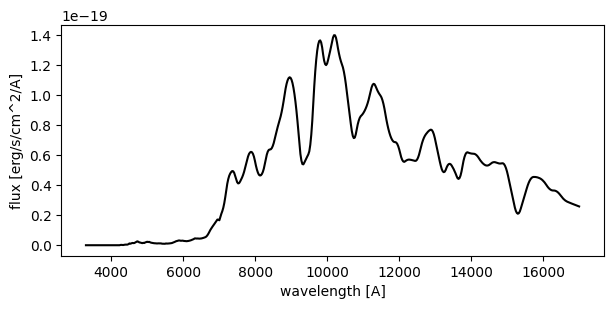

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial", color="k")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Link with `Spectrograph`

In practice the lbda is given by the spectrograph. In the code that is simply done as follows

In [17]:
import slicersim

In [18]:
spectro_config = iotools.get_config()["spectrograph"]
spectrograph = slicersim.Spectrograph.from_config(spectro_config)

In [19]:
lbda, flux = supernovae.get_spectrum(spectrograph.lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

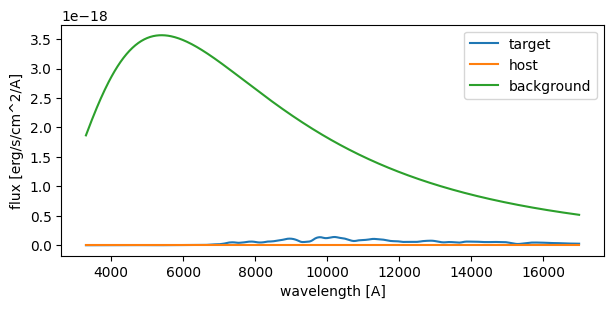

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, fluxes[0], label="target")
ax.plot(lbda, fluxes[1], label="host")
ax.plot(lbda, fluxes[2], label="background")

ax.legend()
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

In [20]:
scene.mutable_parameters

['lbda',
 'target.position',
 'target.abmag',
 'target.phase',
 'target.redshift',
 'target.MBmax',
 'target.source',
 'target.cosmo',
 'target.x1',
 'target.c',
 'target.alpha',
 'target.beta',
 'target.abmag',
 'background.scale',
 'background.model']